# Лабораторная работа №1

**Дисциплина:** алгоритмы эволюционной оптимизации  
**Тема:** реализация простого генетического алгоритма с визуализацией результатов и использованием функций.

Цель работы — реализовать простой генетический алгоритм для минимизации двумерной функции Экли, визуализировать процесс эволюции популяции и сравнить найденный минимум с теоретическим.

## Постановка задачи

Функция Экли для двумерного случая:

$$
f(x, y) = -20 e^{-0.2 \sqrt{(x^2 + y^2) / 2}} - e^{(\cos(2\pi x) + \cos(2\pi y)) / 2} + 20 + e
$$

Глобальный минимум функции находится в точке:

$$
f(0, 0) = 0
$$

В работе используется область поиска `[-5, 5]` по каждой координате.

## Импорт библиотек и параметры алгоритма

Особь кодируется вещественным вектором из двух координат `(x, y)`. Так как выполняется минимизация, приспособленность задается как `fitness = 1 / (1 + f(x, y))`: чем меньше значение функции, тем выше приспособленность.

In [36]:
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


@dataclass(frozen=True)
class GeneticAlgorithmConfig:
    """Параметры генетического алгоритма и области поиска."""

    dimensions: int = 2
    bounds: tuple[float, float] = (-5.0, 5.0)
    population_size: int = 120
    generations: int = 100
    tournament_size: int = 3
    crossover_rate: float = 0.9
    mutation_rate: float = 0.15
    mutation_sigma: float = 0.30
    elite_size: int = 2
    random_seed: int = 42


@dataclass
class GenerationStats:
    """Статистика одного поколения популяции."""

    generation: int
    average_fitness: float
    max_fitness: float
    best_value: float
    diversity: int


@dataclass
class ExperimentResult:
    """Итог работы алгоритма и данные для визуализации."""

    best_position: np.ndarray
    best_value: float
    stats: list[GenerationStats]
    snapshots: dict[int, np.ndarray]
    snapshot_values: dict[int, np.ndarray]


config = GeneticAlgorithmConfig()
config

GeneticAlgorithmConfig(dimensions=2, bounds=(-5.0, 5.0), population_size=120, generations=100, tournament_size=3, crossover_rate=0.9, mutation_rate=0.15, mutation_sigma=0.3, elite_size=2, random_seed=42)

## Функция Экли и оценка популяции

In [37]:
def ackley(points: np.ndarray) -> np.ndarray:
    """Вычисляет значение функции Экли для одной точки или массива точек."""
    x = np.atleast_2d(points)
    dimensions = x.shape[1]
    sum_squares = np.sum(x**2, axis=1)
    sum_cosines = np.sum(np.cos(2.0 * np.pi * x), axis=1)

    return (
        -20.0 * np.exp(-0.2 * np.sqrt(sum_squares / dimensions))
        - np.exp(sum_cosines / dimensions)
        + 20.0
        + np.e
    )


def calculate_fitness(objective_values: np.ndarray) -> np.ndarray:
    """Переводит значения минимизируемой функции в приспособленность."""
    return 1.0 / (1.0 + objective_values)


def initialize_population(config: GeneticAlgorithmConfig, rng: np.random.Generator) -> np.ndarray:
    """Создает начальную популяцию в заданных границах поиска."""
    low, high = config.bounds
    return rng.uniform(low, high, size=(config.population_size, config.dimensions))


def evaluate_population(population: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Считает целевую функцию и приспособленность для всей популяции."""
    objective_values = ackley(population)
    fitness = calculate_fitness(objective_values)
    return objective_values, fitness


def calculate_diversity(population: np.ndarray, decimals: int = 3) -> int:
    """Оценивает разнообразие как число уникальных округленных особей."""
    rounded_population = np.round(population, decimals=decimals)
    return int(np.unique(rounded_population, axis=0).shape[0])

## Операторы генетического алгоритма

В алгоритме используются турнирный отбор, арифметическое скрещивание, гауссова мутация и элитизм.

In [ ]:
def tournament_selection(
    population: np.ndarray,
    fitness: np.ndarray,
    config: GeneticAlgorithmConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """Выбирает одного родителя турниром между случайными кандидатами."""
    selected_indices = rng.integers(0, len(population), size=config.tournament_size)
    winner_index = selected_indices[np.argmax(fitness[selected_indices])]
    return population[winner_index].copy()


def crossover(
    parent_a: np.ndarray,
    parent_b: np.ndarray,
    config: GeneticAlgorithmConfig,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Создает двух потомков арифметическим скрещиванием родителей."""
    if rng.random() > config.crossover_rate:
        return parent_a.copy(), parent_b.copy()

    alpha = rng.random(config.dimensions)
    child_a = alpha * parent_a + (1.0 - alpha) * parent_b
    child_b = alpha * parent_b + (1.0 - alpha) * parent_a
    return child_a, child_b


def mutate(
    individual: np.ndarray,
    config: GeneticAlgorithmConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """Случайно изменяет координаты особи и удерживает их в границах."""
    mutation_mask = rng.random(config.dimensions) < config.mutation_rate
    if np.any(mutation_mask):
        individual = individual.copy()
        individual[mutation_mask] += rng.normal(0.0, config.mutation_sigma, size=np.sum(mutation_mask))
    return np.clip(individual, config.bounds[0], config.bounds[1])


def create_next_generation(
    population: np.ndarray,
    objective_values: np.ndarray,
    fitness: np.ndarray,
    config: GeneticAlgorithmConfig,
    rng: np.random.Generator,
) -> np.ndarray:
    """Формирует новое поколение из элиты и потомков."""
    elite_indices = np.argsort(objective_values)[: config.elite_size]
    next_population = [population[index].copy() for index in elite_indices]

    while len(next_population) < config.population_size:
        parent_a = tournament_selection(population, fitness, config, rng)
        parent_b = tournament_selection(population, fitness, config, rng)
        child_a, child_b = crossover(parent_a, parent_b, config, rng)
        next_population.append(mutate(child_a, config, rng))

        if len(next_population) < config.population_size:
            next_population.append(mutate(child_b, config, rng))

    return np.array(next_population)

## Запуск генетического алгоритма

In [39]:
def collect_stats(
    generation: int,
    population: np.ndarray,
    objective_values: np.ndarray,
    fitness: np.ndarray,
) -> GenerationStats:
    """Собирает численные показатели текущего поколения."""
    return GenerationStats(
        generation=generation,
        average_fitness=float(np.mean(fitness)),
        max_fitness=float(np.max(fitness)),
        best_value=float(np.min(objective_values)),
        diversity=calculate_diversity(population),
    )


def run_genetic_algorithm(config: GeneticAlgorithmConfig) -> ExperimentResult:
    """Запускает полный цикл генетического алгоритма."""
    rng = np.random.default_rng(config.random_seed)
    population = initialize_population(config, rng)
    snapshot_generations = {0, 1, 5, 10, 25, 50, 75, config.generations}

    snapshots: dict[int, np.ndarray] = {}
    snapshot_values: dict[int, np.ndarray] = {}
    stats: list[GenerationStats] = []
    best_position: np.ndarray | None = None
    best_value = float("inf")

    for generation in range(config.generations + 1):
        objective_values, fitness = evaluate_population(population)
        current_best_index = int(np.argmin(objective_values))
        current_best_value = float(objective_values[current_best_index])

        if current_best_value < best_value:
            best_value = current_best_value
            best_position = population[current_best_index].copy()

        stats.append(collect_stats(generation, population, objective_values, fitness))

        if generation in snapshot_generations:
            snapshots[generation] = population.copy()
            snapshot_values[generation] = objective_values.copy()

        if generation < config.generations:
            population = create_next_generation(population, objective_values, fitness, config, rng)

    return ExperimentResult(
        best_position=best_position,
        best_value=best_value,
        stats=stats,
        snapshots=snapshots,
        snapshot_values=snapshot_values,
    )


result = run_genetic_algorithm(config)
first_generation = result.stats[0]
last_generation = result.stats[-1]

print(f"Лучшее найденное решение: x = {result.best_position[0]:.12e}, y = {result.best_position[1]:.12e}")
print(f"Значение функции Экли: {result.best_value:.12e}")
print("Теоретический минимум: 0.0 в точке (0, 0)")
print(f"Абсолютная ошибка: {abs(result.best_value):.12e}")

Лучшее найденное решение: x = 3.223971234042e-16, y = -1.764024351898e-16
Значение функции Экли: 4.440892098501e-16
Теоретический минимум: 0.0 в точке (0, 0)
Абсолютная ошибка: 4.440892098501e-16


## График средней и максимальной приспособленности

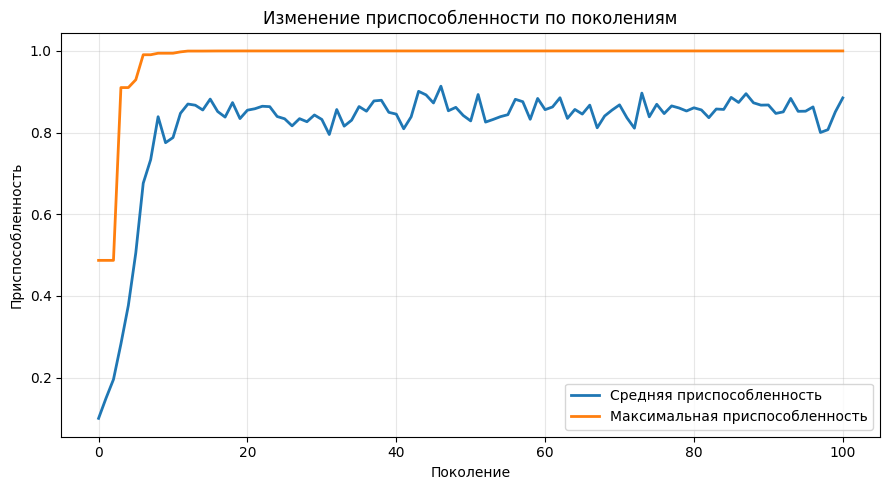

In [40]:
generations = [item.generation for item in result.stats]
average_fitness = [item.average_fitness for item in result.stats]
max_fitness = [item.max_fitness for item in result.stats]

plt.figure(figsize=(9, 5))
plt.plot(generations, average_fitness, label="Средняя приспособленность", linewidth=2)
plt.plot(generations, max_fitness, label="Максимальная приспособленность", linewidth=2)
plt.xlabel("Поколение")
plt.ylabel("Приспособленность")
plt.title("Изменение приспособленности по поколениям")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Распределение особей в пространстве решений

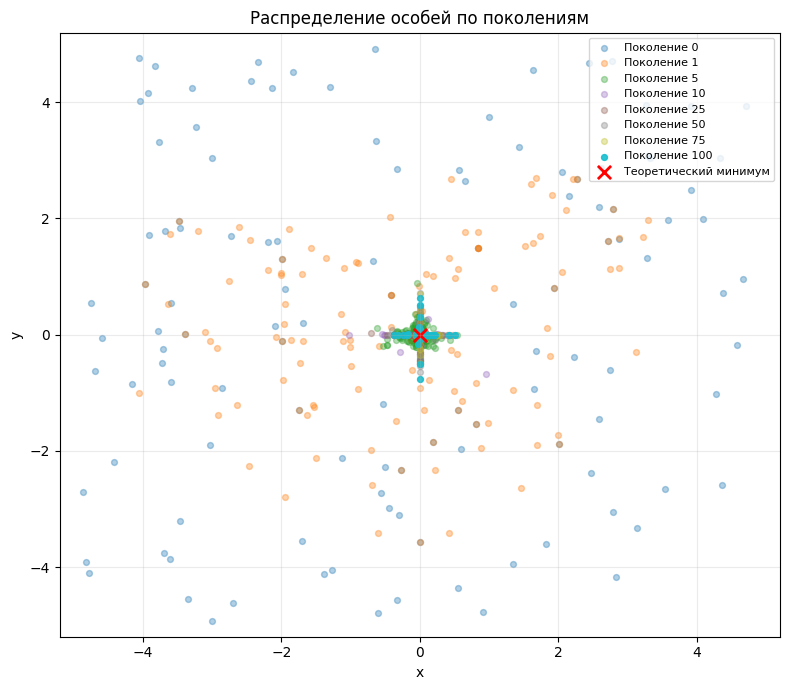

In [41]:
plt.figure(figsize=(8, 7))
ordered_generations = sorted(result.snapshots)
colors = plt.cm.tab10(np.linspace(0, 1, len(ordered_generations)))

for color, generation in zip(colors, ordered_generations):
    population = result.snapshots[generation]

    plt.scatter(
        population[:, 0],
        population[:, 1],
        color=color,
        s=18,
        alpha=0.35 if generation != ordered_generations[-1] else 0.9,
        label=f"Поколение {generation}",
    )

plt.scatter(
    [0.0],
    [0.0],
    marker="x",
    c="red",
    s=90,
    linewidths=2,
    label="Теоретический минимум",
)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Распределение особей по поколениям")
plt.xlim(-5.2, 5.2)
plt.ylim(-5.2, 5.2)
plt.grid(alpha=0.25)
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()


## 3D-поверхность функции Экли

На трехмерном графике поверхность показывает значение функции `f(x, y)`, а точки показывают особей финального поколения. Красный крест отмечает теоретический минимум.

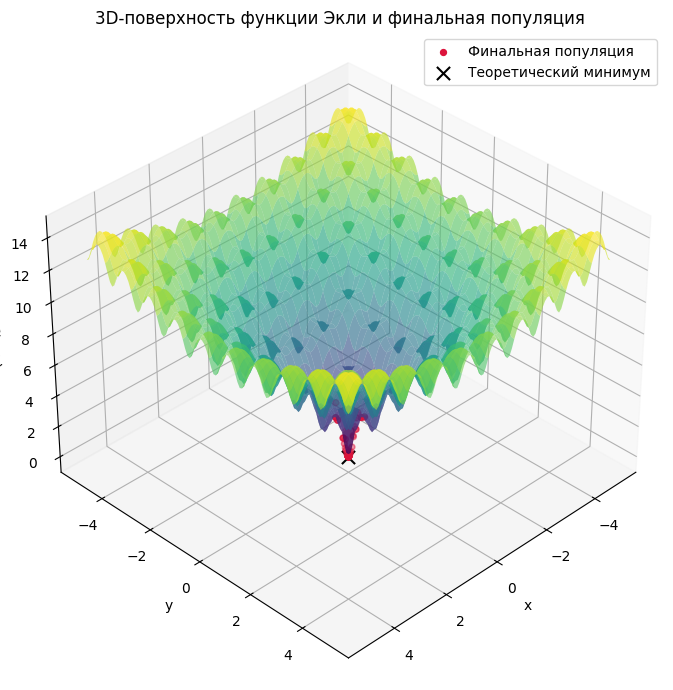

In [42]:
grid = np.linspace(config.bounds[0], config.bounds[1], 120)
X, Y = np.meshgrid(grid, grid)
grid_points = np.column_stack([X.ravel(), Y.ravel()])
Z = ackley(grid_points).reshape(X.shape)

final_population = result.snapshots[config.generations]
final_values = result.snapshot_values[config.generations]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.62, linewidth=0, antialiased=True)
ax.scatter(
    final_population[:, 0],
    final_population[:, 1],
    final_values,
    c="crimson",
    s=18,
    depthshade=True,
    label="Финальная популяция",
)
ax.scatter([0.0], [0.0], [0.0], c="black", marker="x", s=90, label="Теоретический минимум")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("3D-поверхность функции Экли и финальная популяция")
ax.view_init(elev=35, azim=45)
ax.legend()
plt.tight_layout()
plt.show()

## График разнообразия популяции

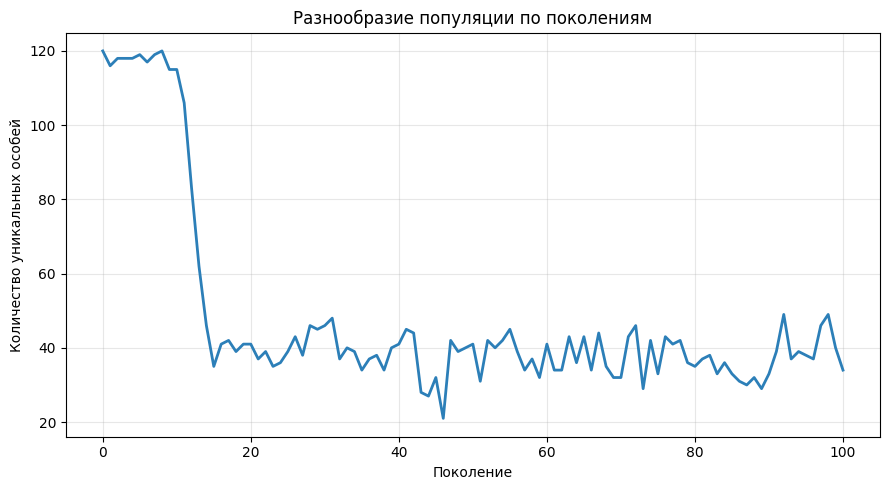

In [43]:
diversity = [item.diversity for item in result.stats]

plt.figure(figsize=(9, 5))
plt.plot(generations, diversity, color="#2c7fb8", linewidth=2)
plt.xlabel("Поколение")
plt.ylabel("Количество уникальных особей")
plt.title("Разнообразие популяции по поколениям")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Сохранение результатов

При необходимости графики и краткая сводка сохраняются в папку `results/`.

In [44]:
notebook_root = Path.cwd()
lab_dir = notebook_root / "EVAL" / "lab_1" if (notebook_root / "EVAL" / "lab_1").exists() else notebook_root
output_dir = lab_dir / "results"
output_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 5))
plt.plot(generations, average_fitness, label="Средняя приспособленность", linewidth=2)
plt.plot(generations, max_fitness, label="Максимальная приспособленность", linewidth=2)
plt.xlabel("Поколение")
plt.ylabel("Приспособленность")
plt.title("Изменение приспособленности по поколениям")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(output_dir / "динамика_приспособленности.png", dpi=160)
plt.close()

plt.figure(figsize=(8, 7))
for color, generation in zip(colors, ordered_generations):
    population = result.snapshots[generation]

    plt.scatter(
        population[:, 0],
        population[:, 1],
        color=color,
        s=18,
        alpha=0.35 if generation != ordered_generations[-1] else 0.9,
        label=f"Поколение {generation}",
    )

plt.scatter([0.0], [0.0], marker="x", c="red", s=90, linewidths=2, label="Теоретический минимум")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Распределение особей по поколениям")
plt.xlim(-5.2, 5.2)
plt.ylim(-5.2, 5.2)
plt.grid(alpha=0.25)
plt.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.savefig(output_dir / "распределение_особей_по_поколениям.png", dpi=160)
plt.close()

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.62, linewidth=0, antialiased=True)
ax.scatter(
    final_population[:, 0],
    final_population[:, 1],
    final_values,
    c="crimson",
    s=18,
    depthshade=True,
    label="Финальная популяция",
)
ax.scatter([0.0], [0.0], [0.0], c="black", marker="x", s=90, label="Теоретический минимум")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")
ax.set_title("3D-поверхность функции Экли и финальная популяция")
ax.view_init(elev=35, azim=45)
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "поверхность_экли_3d.png", dpi=160)
plt.close()

plt.figure(figsize=(9, 5))
plt.plot(generations, diversity, color="#2c7fb8", linewidth=2)
plt.xlabel("Поколение")
plt.ylabel("Количество уникальных особей")
plt.title("Разнообразие популяции по поколениям")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(output_dir / "разнообразие_популяции.png", dpi=160)
plt.close()

summary = f"""Лабораторная работа N1
Тема: простой генетический алгоритм для минимизации функции Экли

Лучшее решение: ({result.best_position[0]:.12e}, {result.best_position[1]:.12e})
Значение функции: {result.best_value:.12e}
Теоретический минимум: 0.0 в точке (0, 0)
Абсолютная ошибка: {abs(result.best_value):.12e}
"""

(output_dir / "summary.txt").write_text(summary, encoding="utf-8")
print(f"Результаты сохранены в: {output_dir.resolve()}")

Результаты сохранены в: C:\Users\motyn\Desktop\repositories\_OMSTU\EVAL\lab_1\results


## Анализ результатов

На начальном поколении популяция распределена по области поиска случайно, поэтому средняя приспособленность мала, а лучшее значение функции заметно отличается от нуля. По мере работы алгоритма отбор, скрещивание и мутация смещают популяцию к области глобального минимума.

При фиксированном seed `42` получены следующие результаты:

- лучшее найденное решение: `(3.2239712340419385e-16, -1.7640243518982355e-16)`;
- значение функции: `4.440892098500626e-16`;
- теоретический минимум: `0` в точке `(0, 0)`;
- абсолютная ошибка: `4.440892098500626e-16`.

Полученное значение отличается от нуля только на уровне машинной погрешности вычислений с плавающей точкой. Разнообразие популяции снижается со `120` уникальных особей в начальном поколении до `34` в последнем поколении, что соответствует сходимости популяции к оптимальной области.

## Вывод

Генетический алгоритм успешно реализует поиск минимума функции Экли. Использование турнирного отбора, арифметического скрещивания, гауссовой мутации и элитизма позволило получить решение, практически совпадающее с теоретическим глобальным минимумом `f(0, 0) = 0`.